# 06 Long Read Inversion Assessment
Here, we visualize the inversions that were identified across all size, depth, and platform treatments for long reads.

In [1]:
library(ggplot2)
library(dplyr)
library(ggpubr)
library(ggpattern)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 12)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## Import Data
### Identified Inversions
Read in the aggregate inversion discovery manifest

In [2]:
found_inversions <- read.table("longread.inversions.summary", header = T)
nrow(found_inversions)
head(found_inversions)

[1] 6497

,sample,size,depth,platform,chrom,start,end,quality
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<chr>
1,sample_01,small,0.5,pacbio,2L,3193195,3214220,LowQual
2,sample_01,small,0.5,ontshort,2L,20107900,20113694,LowQual
3,sample_01,small,2.0,pacbio,2L,3193195,3214220,LowQual
4,sample_01,small,2.0,pacbio,2L,3940210,3944862,PASS
5,sample_01,small,2.0,pacbio,2L,3940211,3944863,PASS
6,sample_01,small,2.0,pacbio,2L,13024406,13026575,PASS


There are approximate duplicates in here, so we need to filter out rows with breakpoints that are within a few bp of each other

In [3]:
remove_nearby_duplicates <- function(df, threshold = 20) {
  n <- nrow(df)
  if (n <= 1) return(df)
  # Sort by start position within each group for efficiency
  df <- df[order(df$start), ]
  keep <- rep(TRUE, n)
  for (i in 1:(n-1)) {
    if (!keep[i]) next
    # Only check rows that could potentially be within threshold
    remaining_idx <- (i+1):n
    start_diffs <- abs(df$start[i] - df$start[remaining_idx])

    # Early exit if start positions are already too far apart (since sorted)
    if (min(start_diffs) > threshold) break

    end_diffs <- abs(df$end[i] - df$end[remaining_idx])

    # Mark rows that are too close
    too_close <- which(start_diffs <= threshold & end_diffs <= threshold)
    if (length(too_close) > 0) {
      keep[remaining_idx[too_close]] <- FALSE
    }
  }

  return(df[keep, ])
}

In [4]:
cleaned_inversions <- found_inversions %>%
  group_by(sample, chrom, size, depth, platform) %>%
  group_modify(~ remove_nearby_duplicates(.x, threshold = 20)) %>%
  ungroup()
nrow(cleaned_inversions)
head(cleaned_inversions, 10)

[1] 4082

sample,chrom,size,depth,platform,start,end,quality
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
sample_01,2L,large,2,ontlong,11529165,15060030,LowQual
sample_01,2L,large,2,ontlong,18872128,20461265,LowQual
sample_01,2L,large,2,ontshort,18872128,20461265,LowQual
sample_01,2L,large,2,pacbio,11529164,15060029,PASS
sample_01,2L,large,2,pacbio,18872128,20461265,LowQual
sample_01,2L,large,5,ontlong,11529164,15060029,PASS
sample_01,2L,large,5,ontlong,18872128,20461265,PASS
sample_01,2L,large,5,ontshort,11529164,15060029,PASS
sample_01,2L,large,5,ontshort,18872128,20461265,PASS


Small sanity check to make sure the deduplication was accurate

In [5]:
filter(found_inversions,   platform == "pacbio", chrom == "2L", size == "small", sample == "sample_01", depth == 5)
filter(cleaned_inversions, platform == "pacbio", chrom == "2L", size == "small",  sample == "sample_01", depth == 5)

sample,size,depth,platform,chrom,start,end,quality
<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<chr>
sample_01,small,5,pacbio,2L,3193195,3214220,PASS
sample_01,small,5,pacbio,2L,3193197,3214220,PASS
sample_01,small,5,pacbio,2L,3940210,3944862,PASS
sample_01,small,5,pacbio,2L,3940211,3944863,PASS
sample_01,small,5,pacbio,2L,13024403,13026576,PASS
sample_01,small,5,pacbio,2L,13024405,13026576,LowQual
sample_01,small,5,pacbio,2L,14845708,14861199,LowQual
sample_01,small,5,pacbio,2L,14845710,14861199,PASS
sample_01,small,5,pacbio,2L,20107900,20113694,PASS


sample,chrom,size,depth,platform,start,end,quality
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
sample_01,2L,small,5,pacbio,3193195,3214220,PASS
sample_01,2L,small,5,pacbio,3940210,3944862,PASS
sample_01,2L,small,5,pacbio,13024403,13026576,PASS
sample_01,2L,small,5,pacbio,14845708,14861199,LowQual
sample_01,2L,small,5,pacbio,20107900,20113694,PASS


### Simulated Inversions
Read in the groundtruth file. To avoid merging the breakpoints with the samples-inversions manifest each time, this process was done once with the code below and written to the file to be imported.

In [6]:
if(!file.exists("manifest.breakpoints")){
    # Get all the inversion breakpoints
    groundtruth <- read.table("../inversion_simulations.inventory", header = T)
    truthfile <- paste0("../simulated_variants/setup_inversions/small/inv.small.vcf")
    inversion_breakpoints <- read.table(truthfile, header = F)[,c(1,2,8)]
    inversion_breakpoints$V8 <- as.numeric(unlist(lapply(inversion_breakpoints$V8, function(X){gsub(".+END=", "", X)})))
    names(inversion_breakpoints) <- c("contig", "position_start", "position_end")
    inversion_breakpoints$size <- "small"
    inversion_breakpoints <- group_by(inversion_breakpoints, contig) %>% mutate(inversion = 1:n())

    for( i in c("medium", "large","xl") ){
        truthfile <- paste0("../simulated_variants/setup_inversions/", i, "/inv.", i,".vcf")
    
        .inversion_breakpoints <- read.table(truthfile, header = F)[,c(1,2,8)]
        .inversion_breakpoints$V8 <- as.numeric(unlist(lapply(.inversion_breakpoints$V8, function(X){gsub(".+END=", "", X)})))
        names(.inversion_breakpoints) <- c("contig", "position_start", "position_end")
        .inversion_breakpoints$size <- i
        .inversion_breakpoints <- group_by(.inversion_breakpoints, contig) %>% mutate(inversion = 1:n())
        inversion_breakpoints <- rbind(inversion_breakpoints, .inversion_breakpoints)
    }
    # Use a join to add breakpoints to the groundtruth
    master_manifest <- merge(groundtruth, inversion_breakpoints, by.x = c("size", "contig","inversion"), by.y = c("size", "contig","inversion"))

    # write it to a table so we don't have to do this over and over
    write.table(master_manifest[c(4,2,7,8,1,5,6)], file = "manifest.breakpoints", row.names = F, quote = F)
}

In [6]:
groundtruth <- read.table("manifest.breakpoints", header = T)
head(groundtruth)

,sample,contig,position_start,position_end,size,present,state
,<chr>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>
1,sample_01,2L,11529165,15060030,large,TRUE,hom
2,sample_08,2L,11529165,15060030,large,TRUE,hom
3,sample_02,2L,11529165,15060030,large,TRUE,hom
4,sample_09,2L,11529165,15060030,large,TRUE,hom
5,sample_03,2L,11529165,15060030,large,TRUE,hom
6,sample_10,2L,11529165,15060030,large,TRUE,hom


Extend the rows to include depth, platform, and state, defaulting the state to false negatives and true negatives. This table will be filled up according to whether an inversion was found, and if found, if it's one of the known inversions.

In [7]:
assessment_df <- groundtruth[0,]
assessment_df$assessment <- character()
assessment_df$depth <- double()
assessment_df$platform <- character()
assessment_df$state <- character()
j <- 0
for(i in 1:nrow(groundtruth)){
    .row <- groundtruth[i,]
    if(.row$present){
        .row$assessment <- "false negative"
    } else {
        .row$assessment <- "true negative"
    }
    for(.depth in c(0.5, 2.0, 5.0, 10.0, 20.0)){
        for(.platform in c("pacbio", "ontlong", "ontshort")){
            j <- j + 1
            .row$depth <- .depth
            .row$platform <- .platform
            assessment_df[j,] <- .row
        }
    }
}
head(assessment_df, 8)

,sample,contig,position_start,position_end,size,present,state,assessment,depth,platform
,<chr>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>,<chr>,<dbl>,<chr>
1,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,pacbio
2,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,ontlong
3,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,0.5,ontshort
4,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,2.0,pacbio
5,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,2.0,ontlong
6,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,2.0,ontshort
7,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,5.0,pacbio
8,sample_01,2L,11529165,15060030,large,TRUE,hom,false negative,5.0,ontlong


## Assess Identified Inversions

The function to do a fuzzy-match to establish if the identified inversions are true/false positives/negatives

In [8]:
cleaned_inversions$assessment <- "false positive"
false_positives <- cleaned_inversions[0,]
for(i in 1:nrow(cleaned_inversions)){
    .row <- cleaned_inversions[i,]
    query <- which(
        assessment_df$sample == .row$sample &
        assessment_df$platform == .row$platform &
        assessment_df$depth == .row$depth &
        assessment_df$contig == .row$chrom &
        assessment_df$size == .row$size &
        assessment_df$position_start - 500 <= .row$start &
        assessment_df$position_end + 500 >= .row$end
    )
    if(length(query) > 0 && assessment_df$present[query]){
        cleaned_inversions$assessment[i] <- "true positive"
        assessment_df$assessment[query] <- "true positive"
    } else {
        print(paste("false positive", query))
        assessment_df$assessment[query] <- "false positive"
        false_positives <- rbind(false_positives, .row)
    }
}


This will have marked the inversions in both `cleaned_inversions` and `assessment_df` as either `true positive` or `false positive`. Let's get a simple overview of performance (and a bit of a sanity check because this logic, although clean, took hours to get right).

In [9]:
table(assessment_df$assessment)
false_positives


false negative  true negative  true positive 
          1584           1950           3666 

sample,chrom,size,depth,platform,start,end,quality,assessment
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>,<chr>


Like the linked-read dataset, these data have no false positives, which is great!

## Plotting the Inversions
We are plotting the inversions across the genome as a visual assessment, along with a presence/absence matrix across platforms and zygotic state. Small inversions were made bigger by 100kb to see them easier on the plot. All other inversions had their lengths increased by 50kb for the same reason.

In [11]:
plot_inversions <- function(data, size_treatment){
    if(size_treatment == "small"){
        scale_factor = 100000
    } else {
        scale_factor = 50000
    }

    filter(data, size == size_treatment, assessment == "true positive") %>%
    ggplot(
        aes(
            x = sample,
            ymin = position_start,
            ymax = position_end + scale_factor,
            color = platform,
        )
    ) +
        scale_y_continuous(labels = scales::comma) +
        coord_flip() +
        geom_linerange(position = position_dodge(.7), linewidth = 2) +
        labs(title = "Called Inversions Across the Genome", subtitle = paste0("Size: ", size_treatment), y = "genomic position (bp)") + 
        facet_grid(cols = vars(contig), rows = vars(depth)) +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "top")
}

plot_samples_matrix <- function(data, size_treatment){
filter(data, size == size_treatment) %>%
    group_by(size, contig, position_start) %>% mutate(id = cur_group_id()) %>% ungroup() %>%
    ggplot(aes(y = sample, x = id, fill = assessment, pattern = state)) +
        geom_tile_pattern(
            pattern_color = NA,
            color = "white",
            pattern_fill = "black",
            pattern_angle = 45,
            pattern_density = 0.5,
            pattern_spacing = 0.025,
            pattern_key_scale_factor = 1
        ) +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = "Inversions detected in individual samples, as a function of zygotic state.", caption = paste0("Size: ", size_treatment)) +
        scale_fill_manual(values = c("false negative" = "#eaf398ff", "true negative" = "grey70", "true positive" = "#90aed8")) +
        scale_pattern_manual(values = c("het" = "circle", "hom" = "none")) +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(rows = vars(depth), cols = vars(platform))
}

### Small Inversions

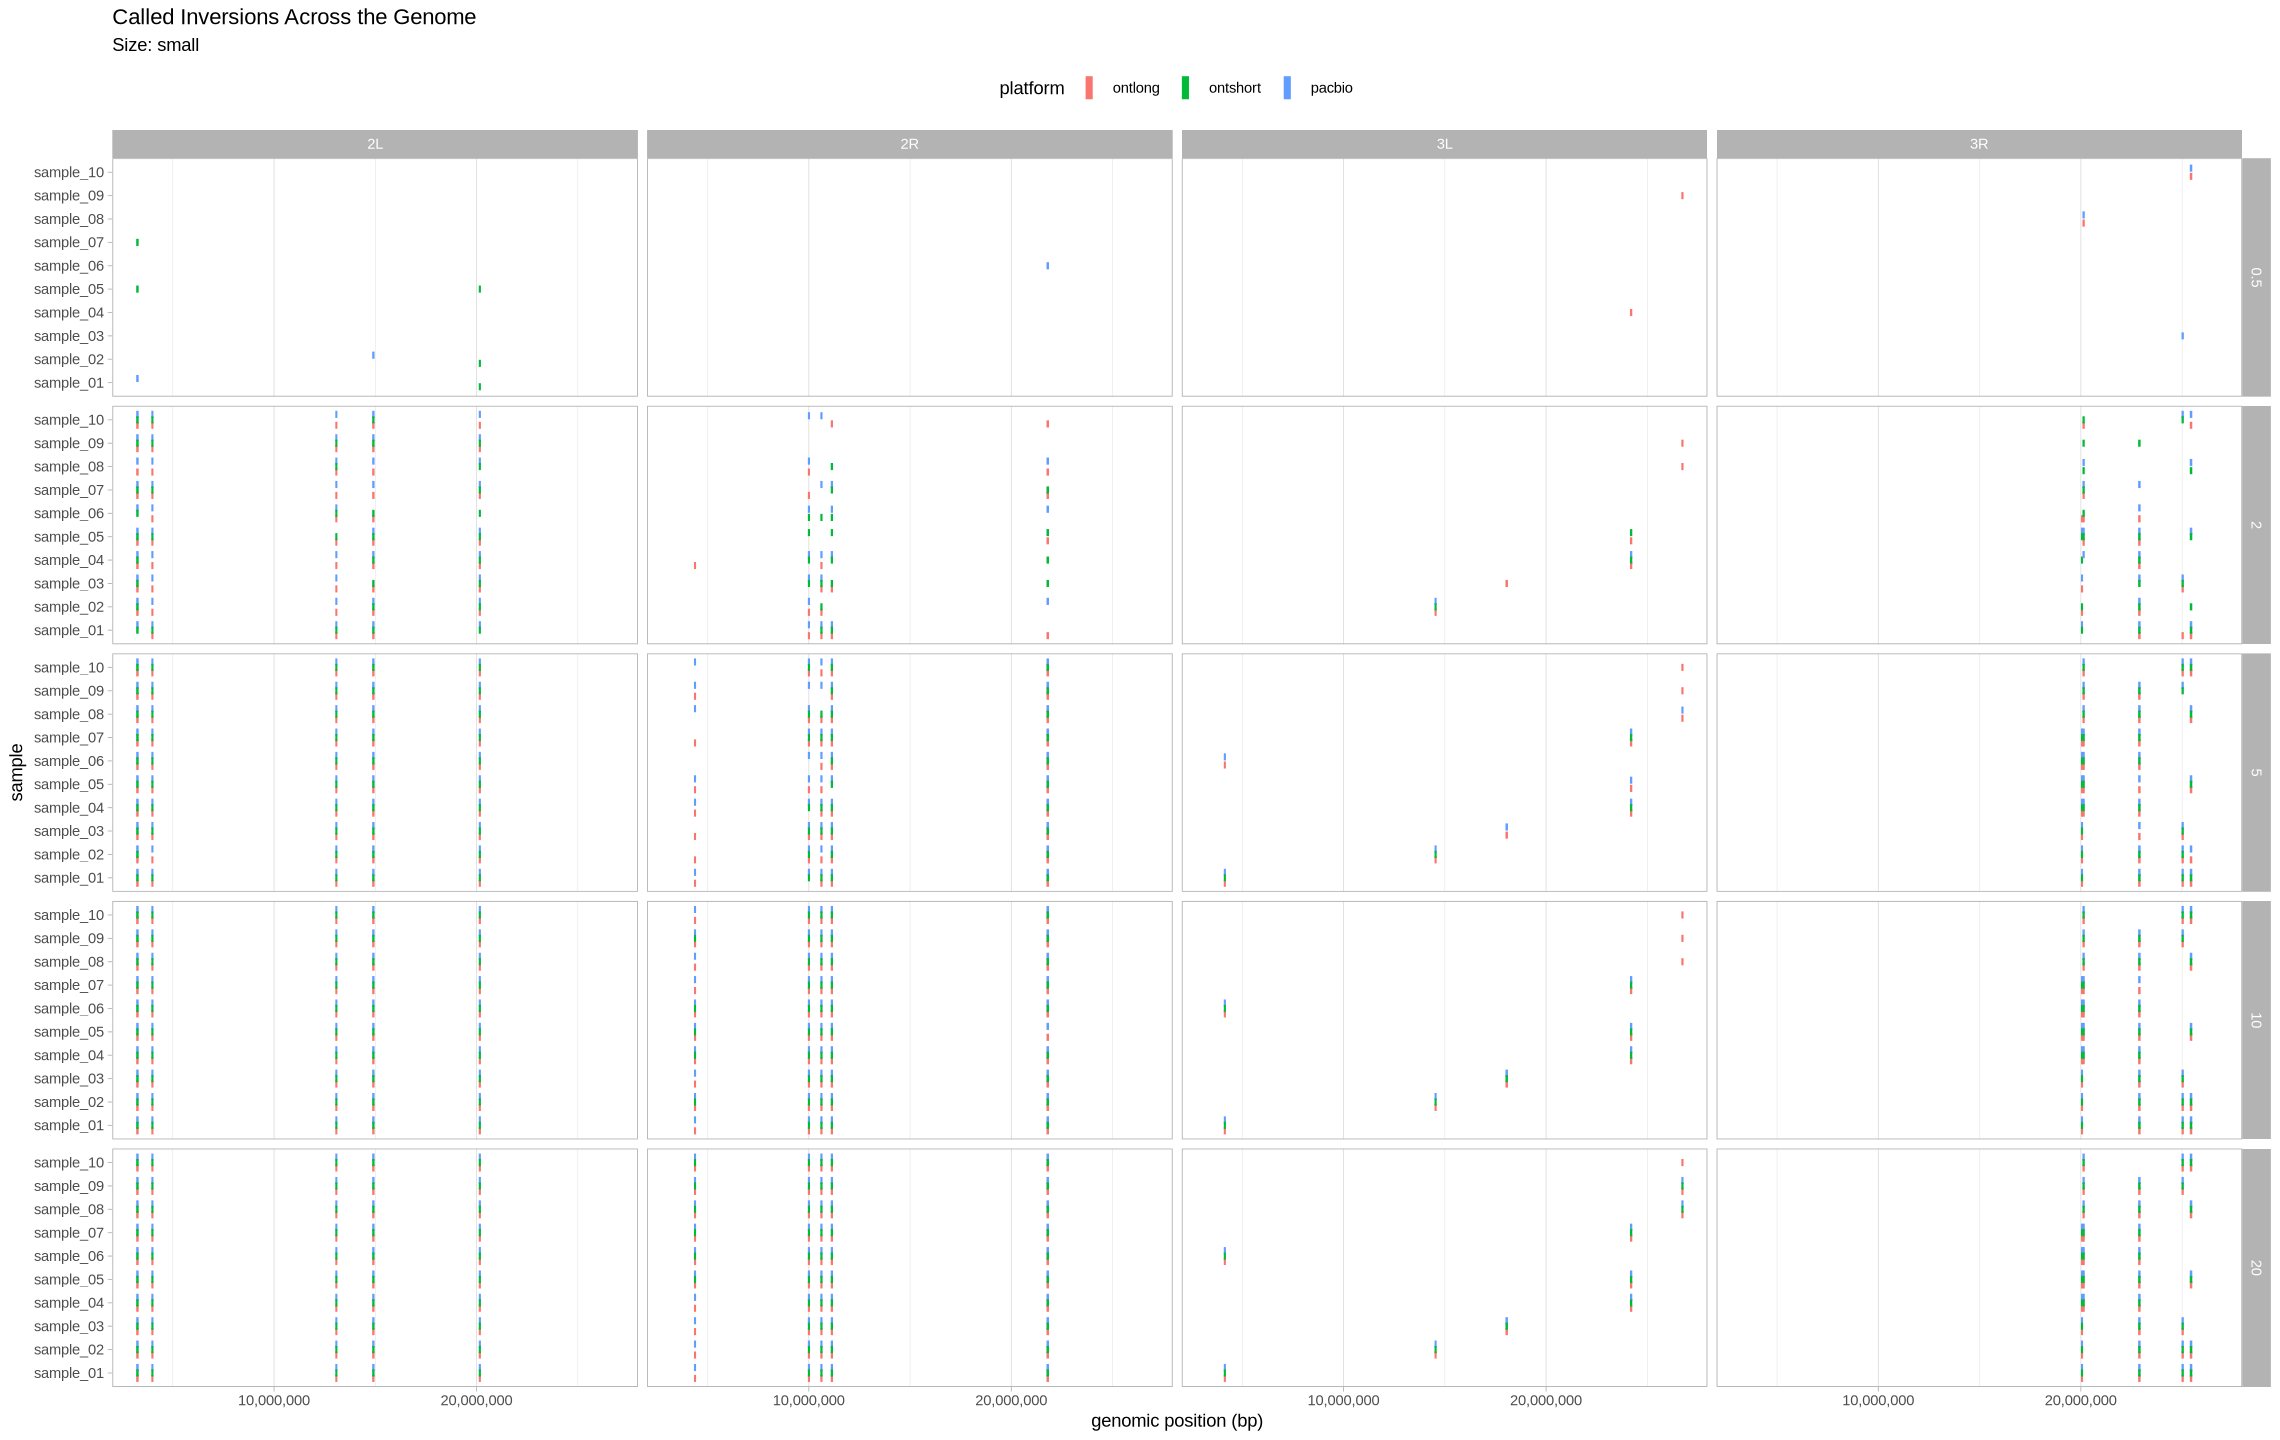

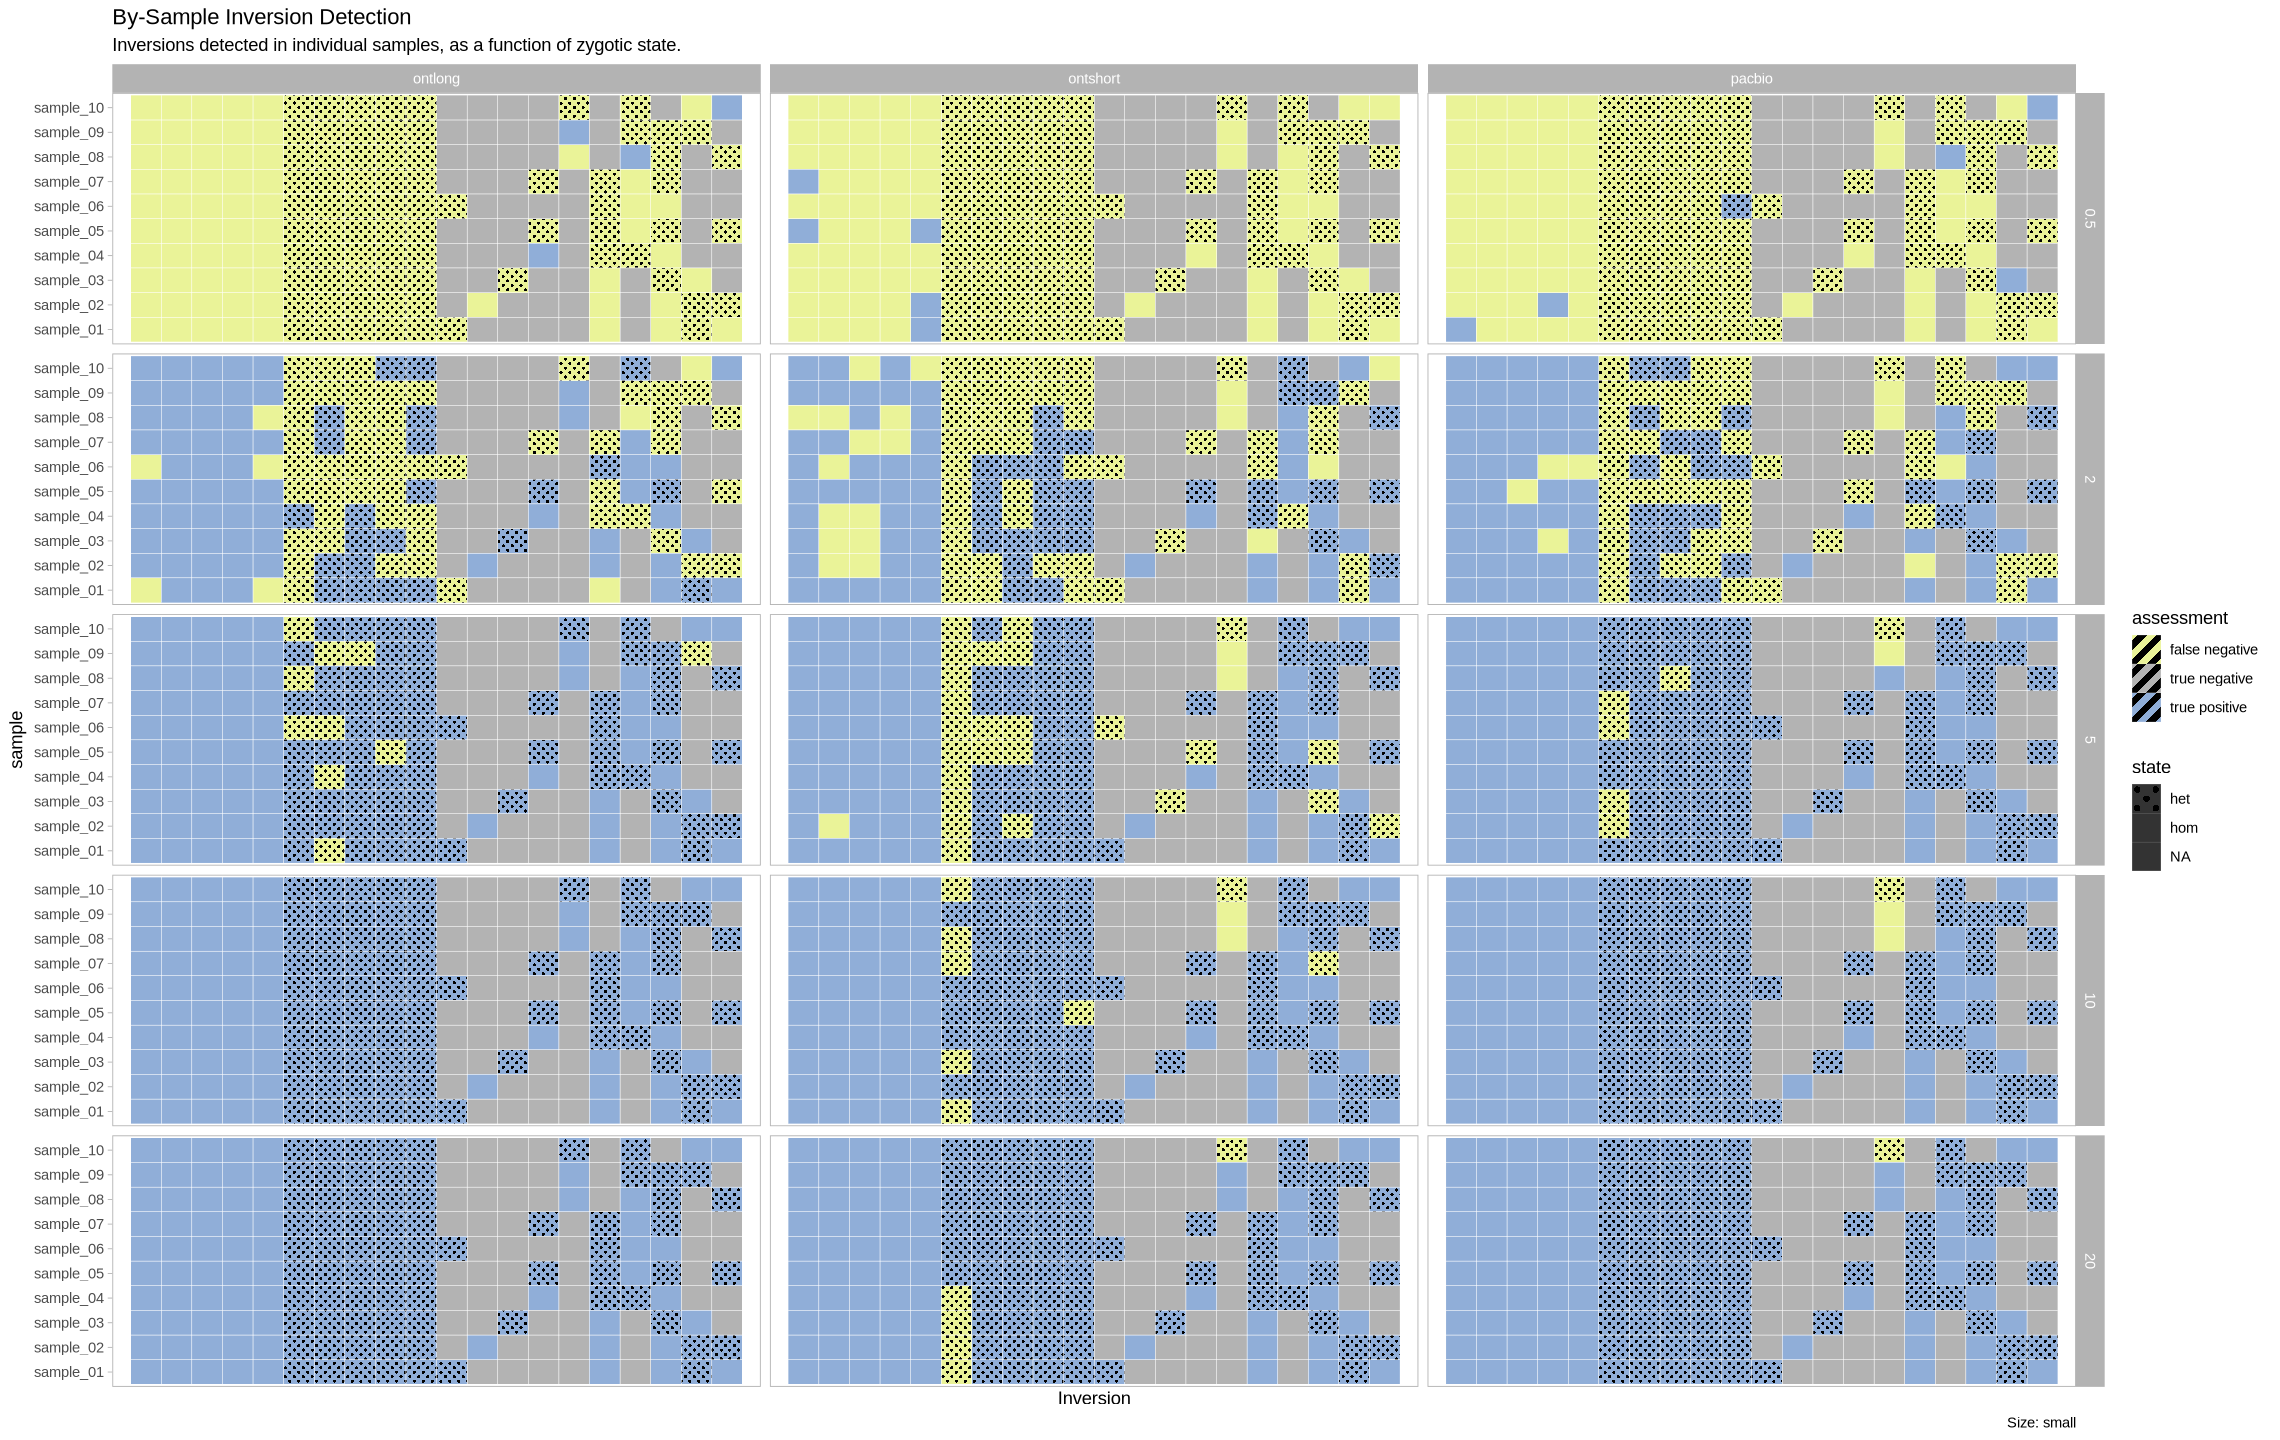

In [12]:
plot_inversions(assessment_df, "small")
plot_samples_matrix(assessment_df, "small")

### Medium Inversions

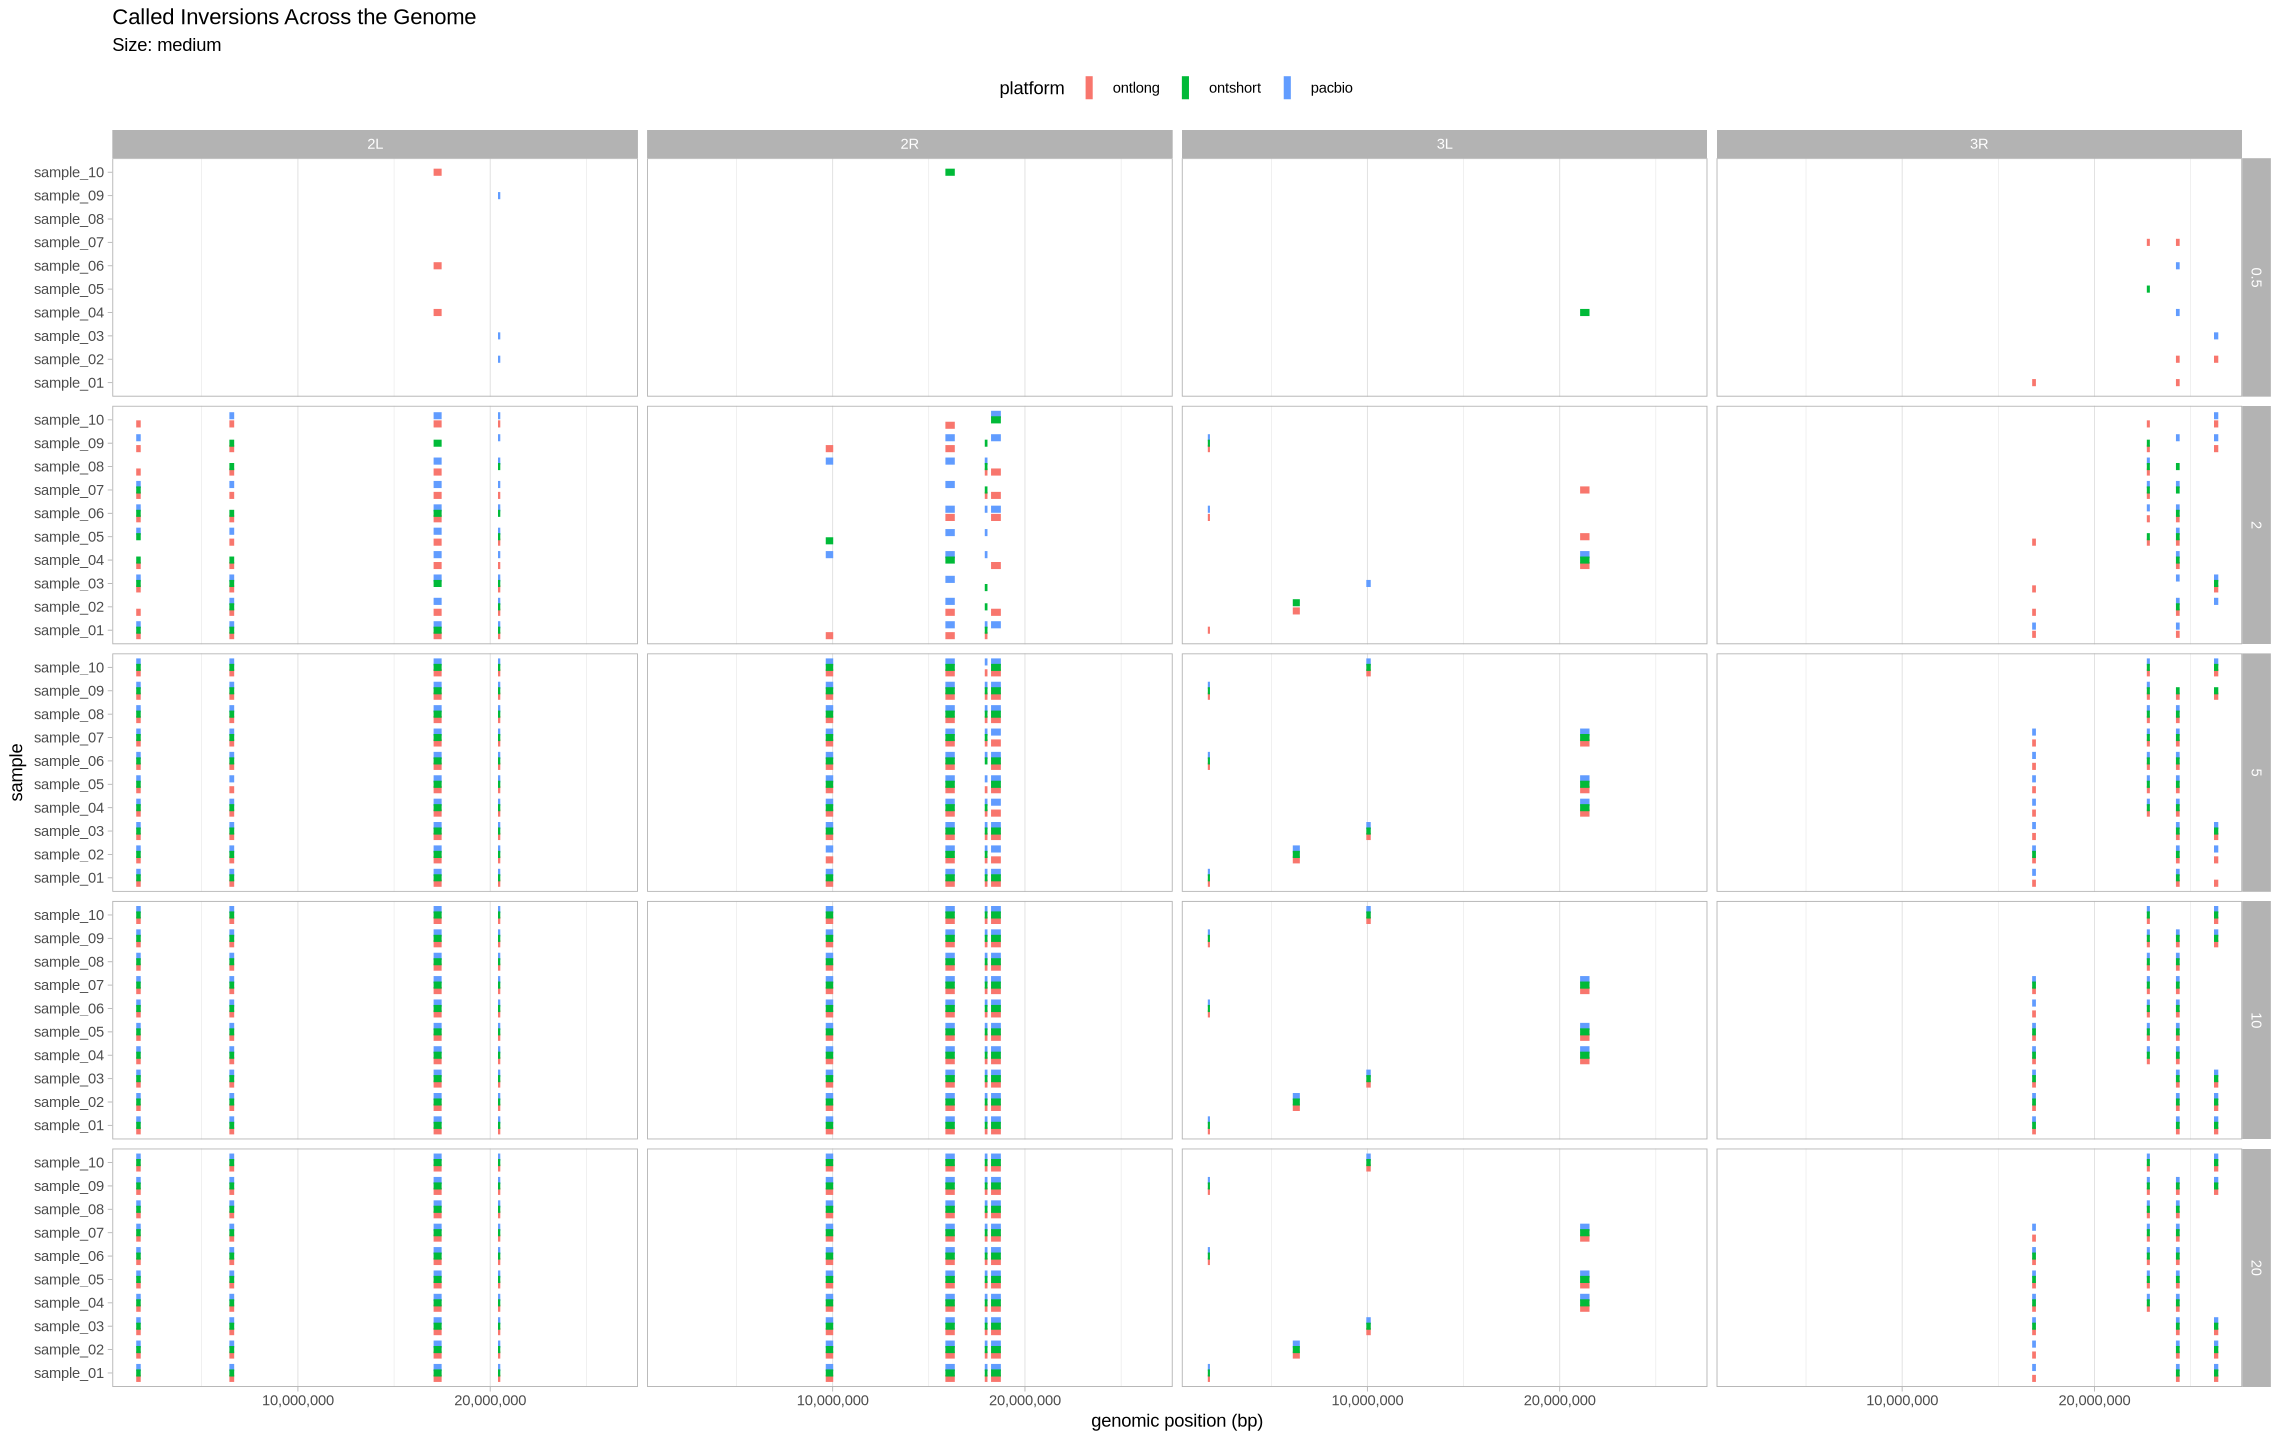

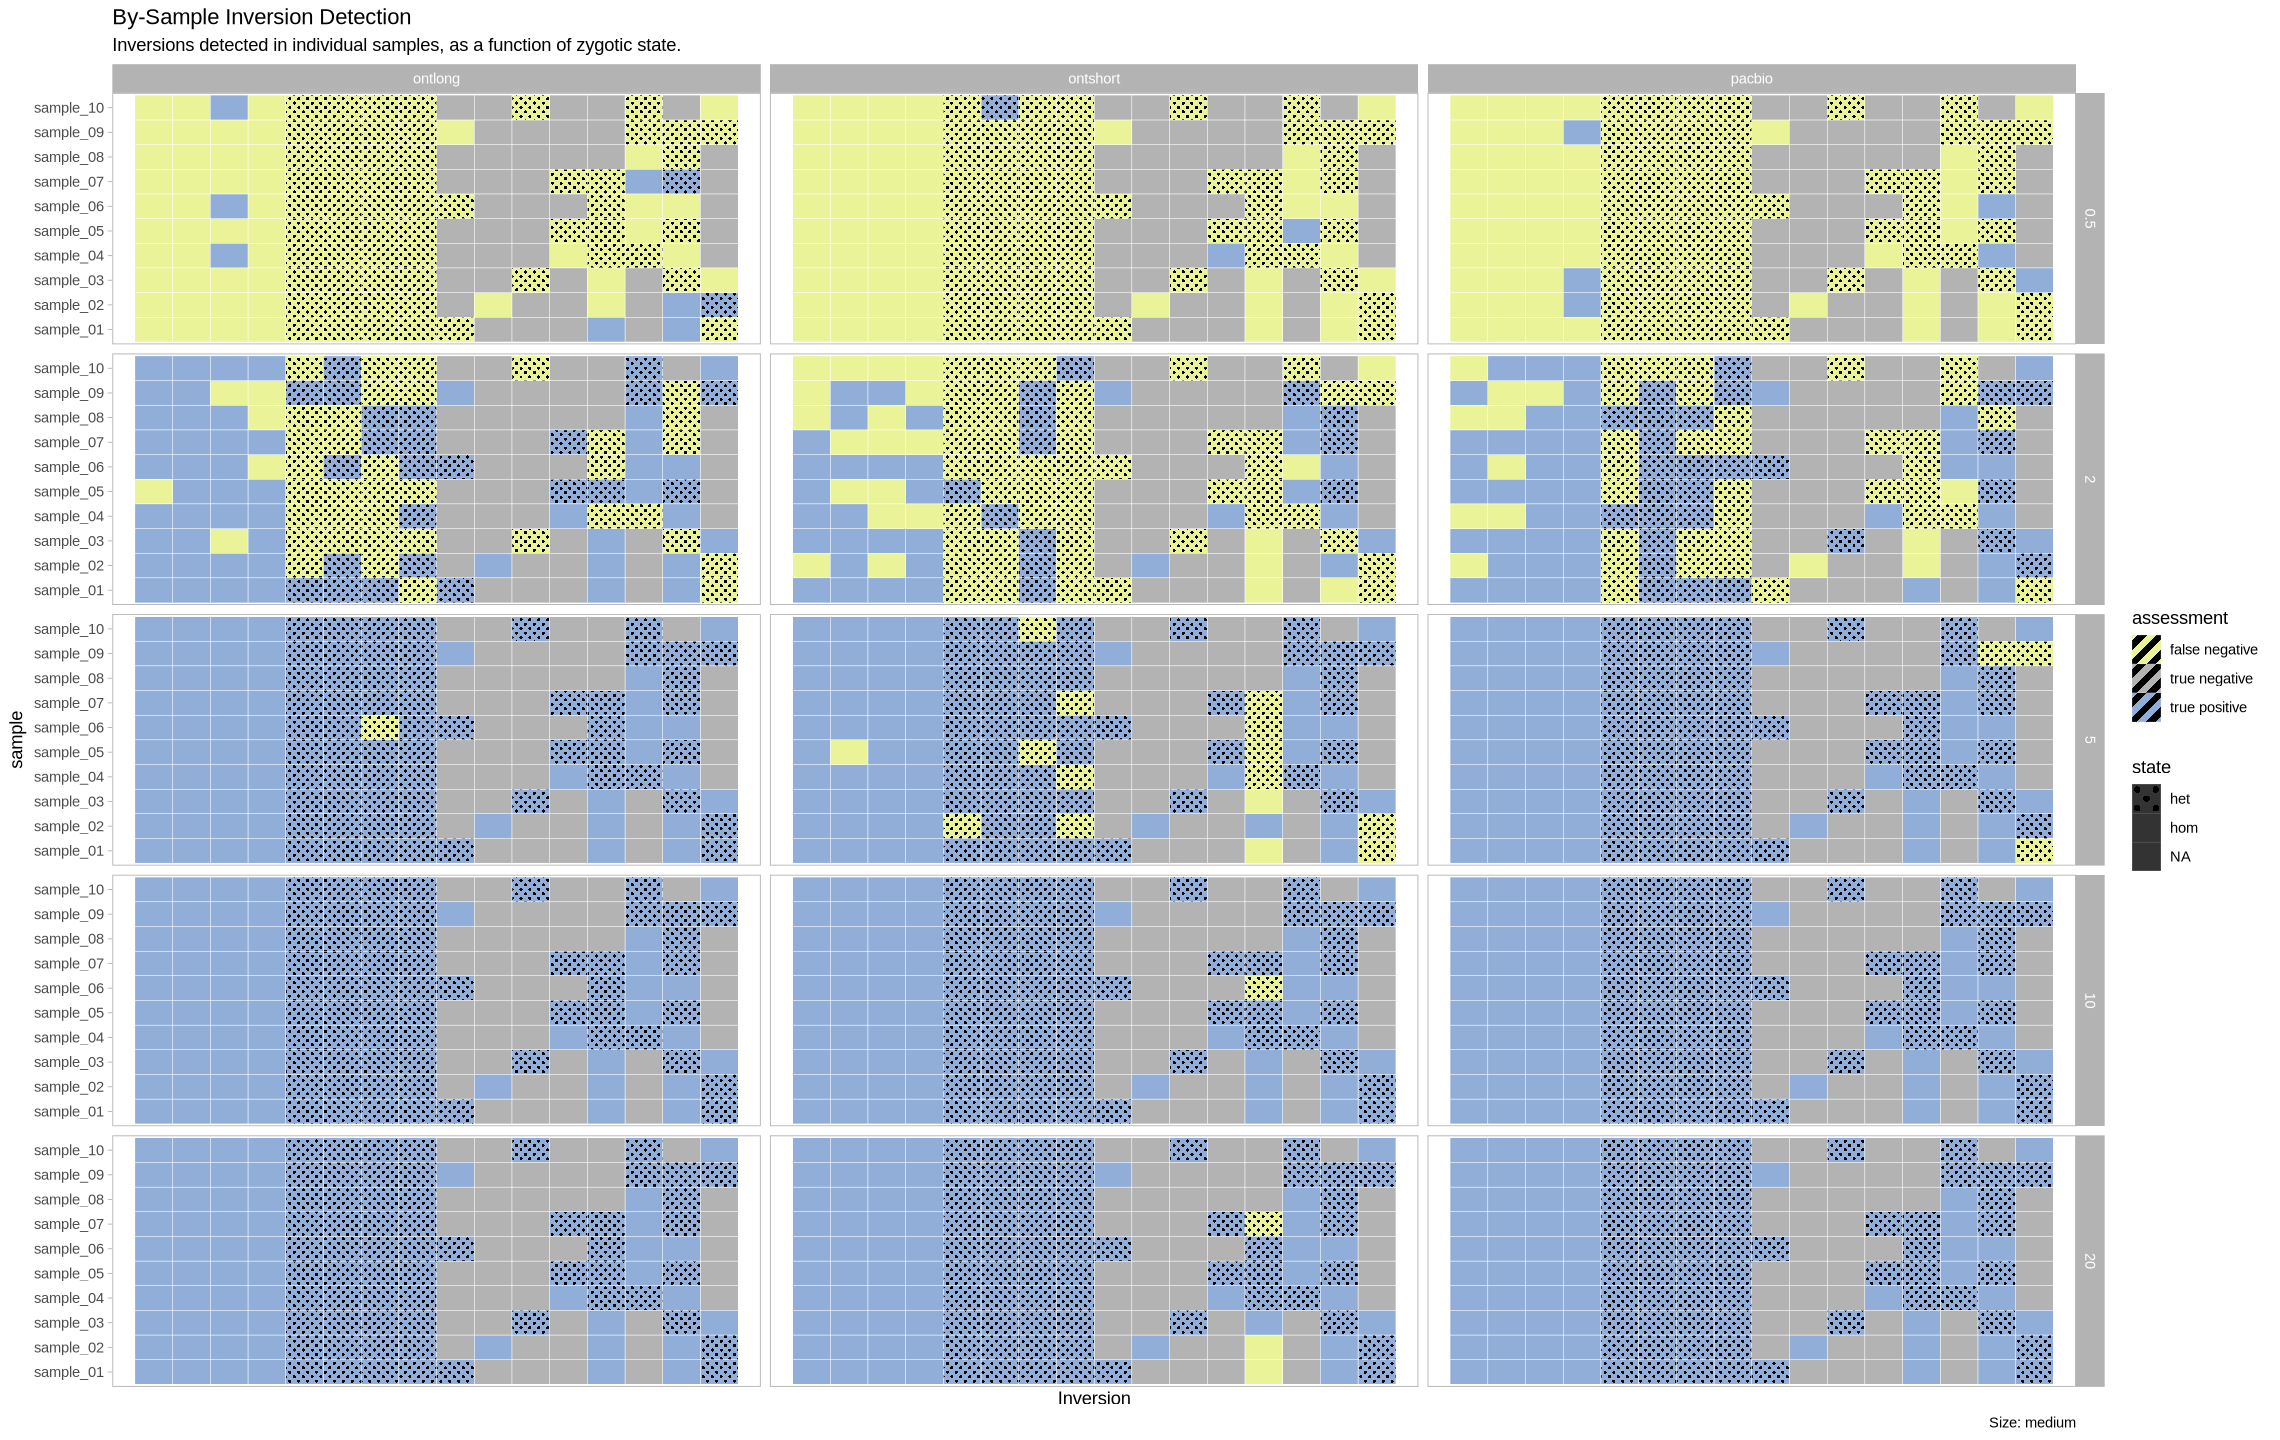

In [13]:
plot_inversions(assessment_df, "medium")
plot_samples_matrix(assessment_df, "medium")

### Large Inversions

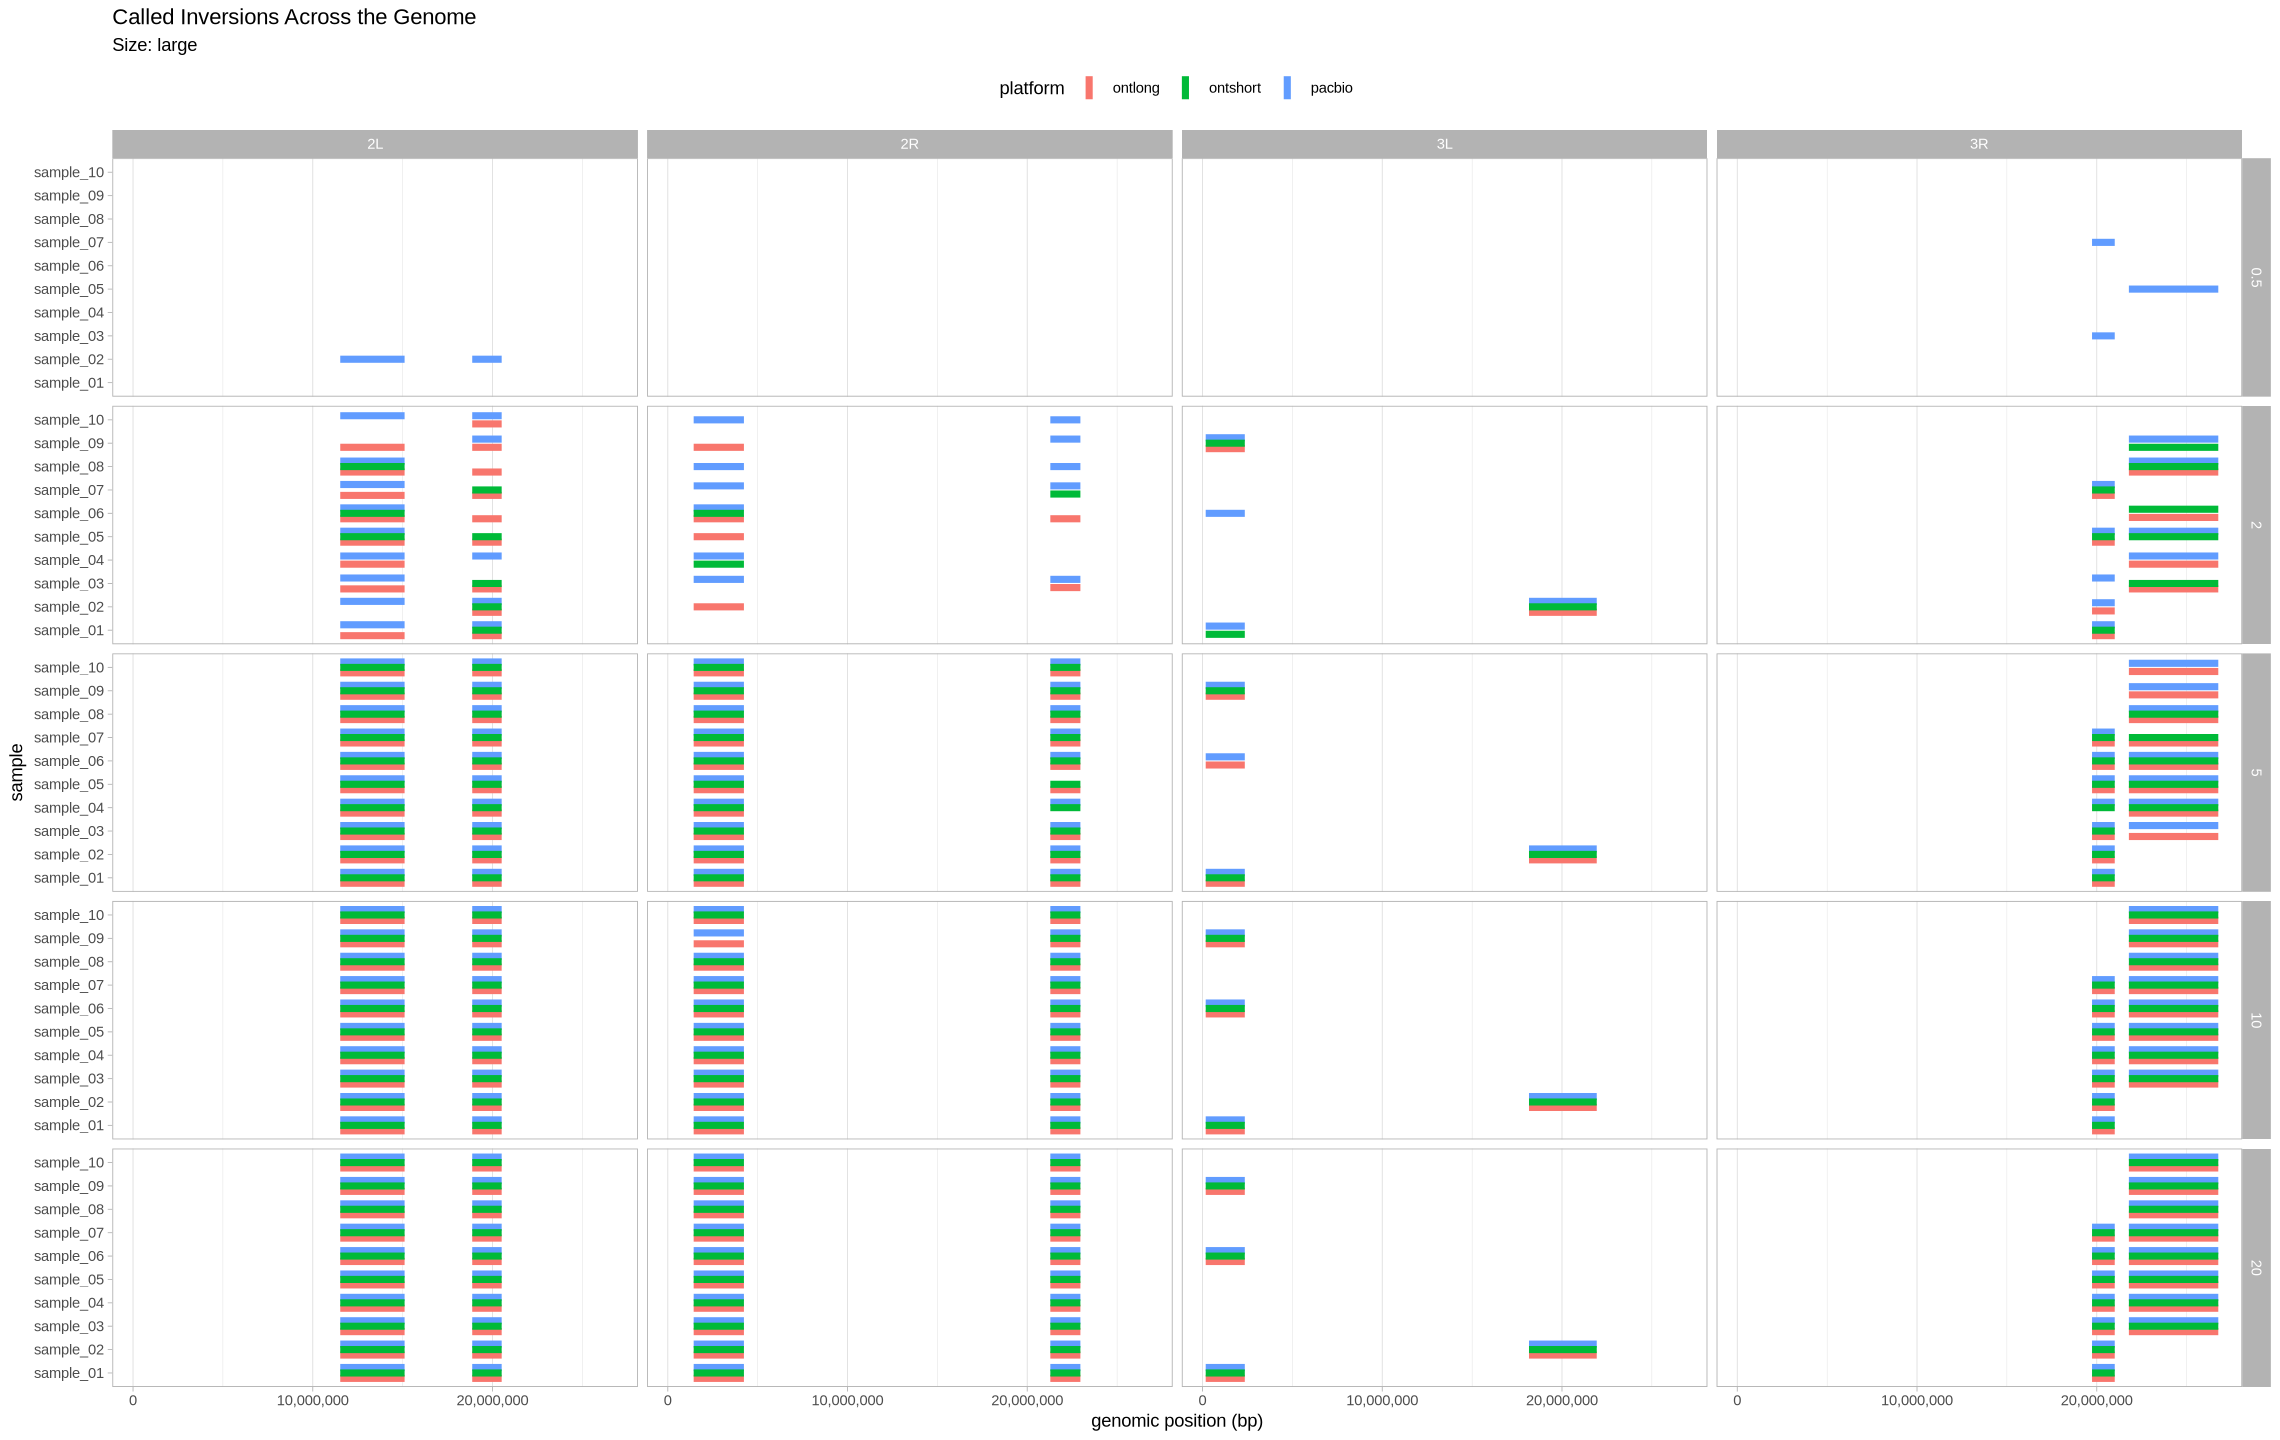

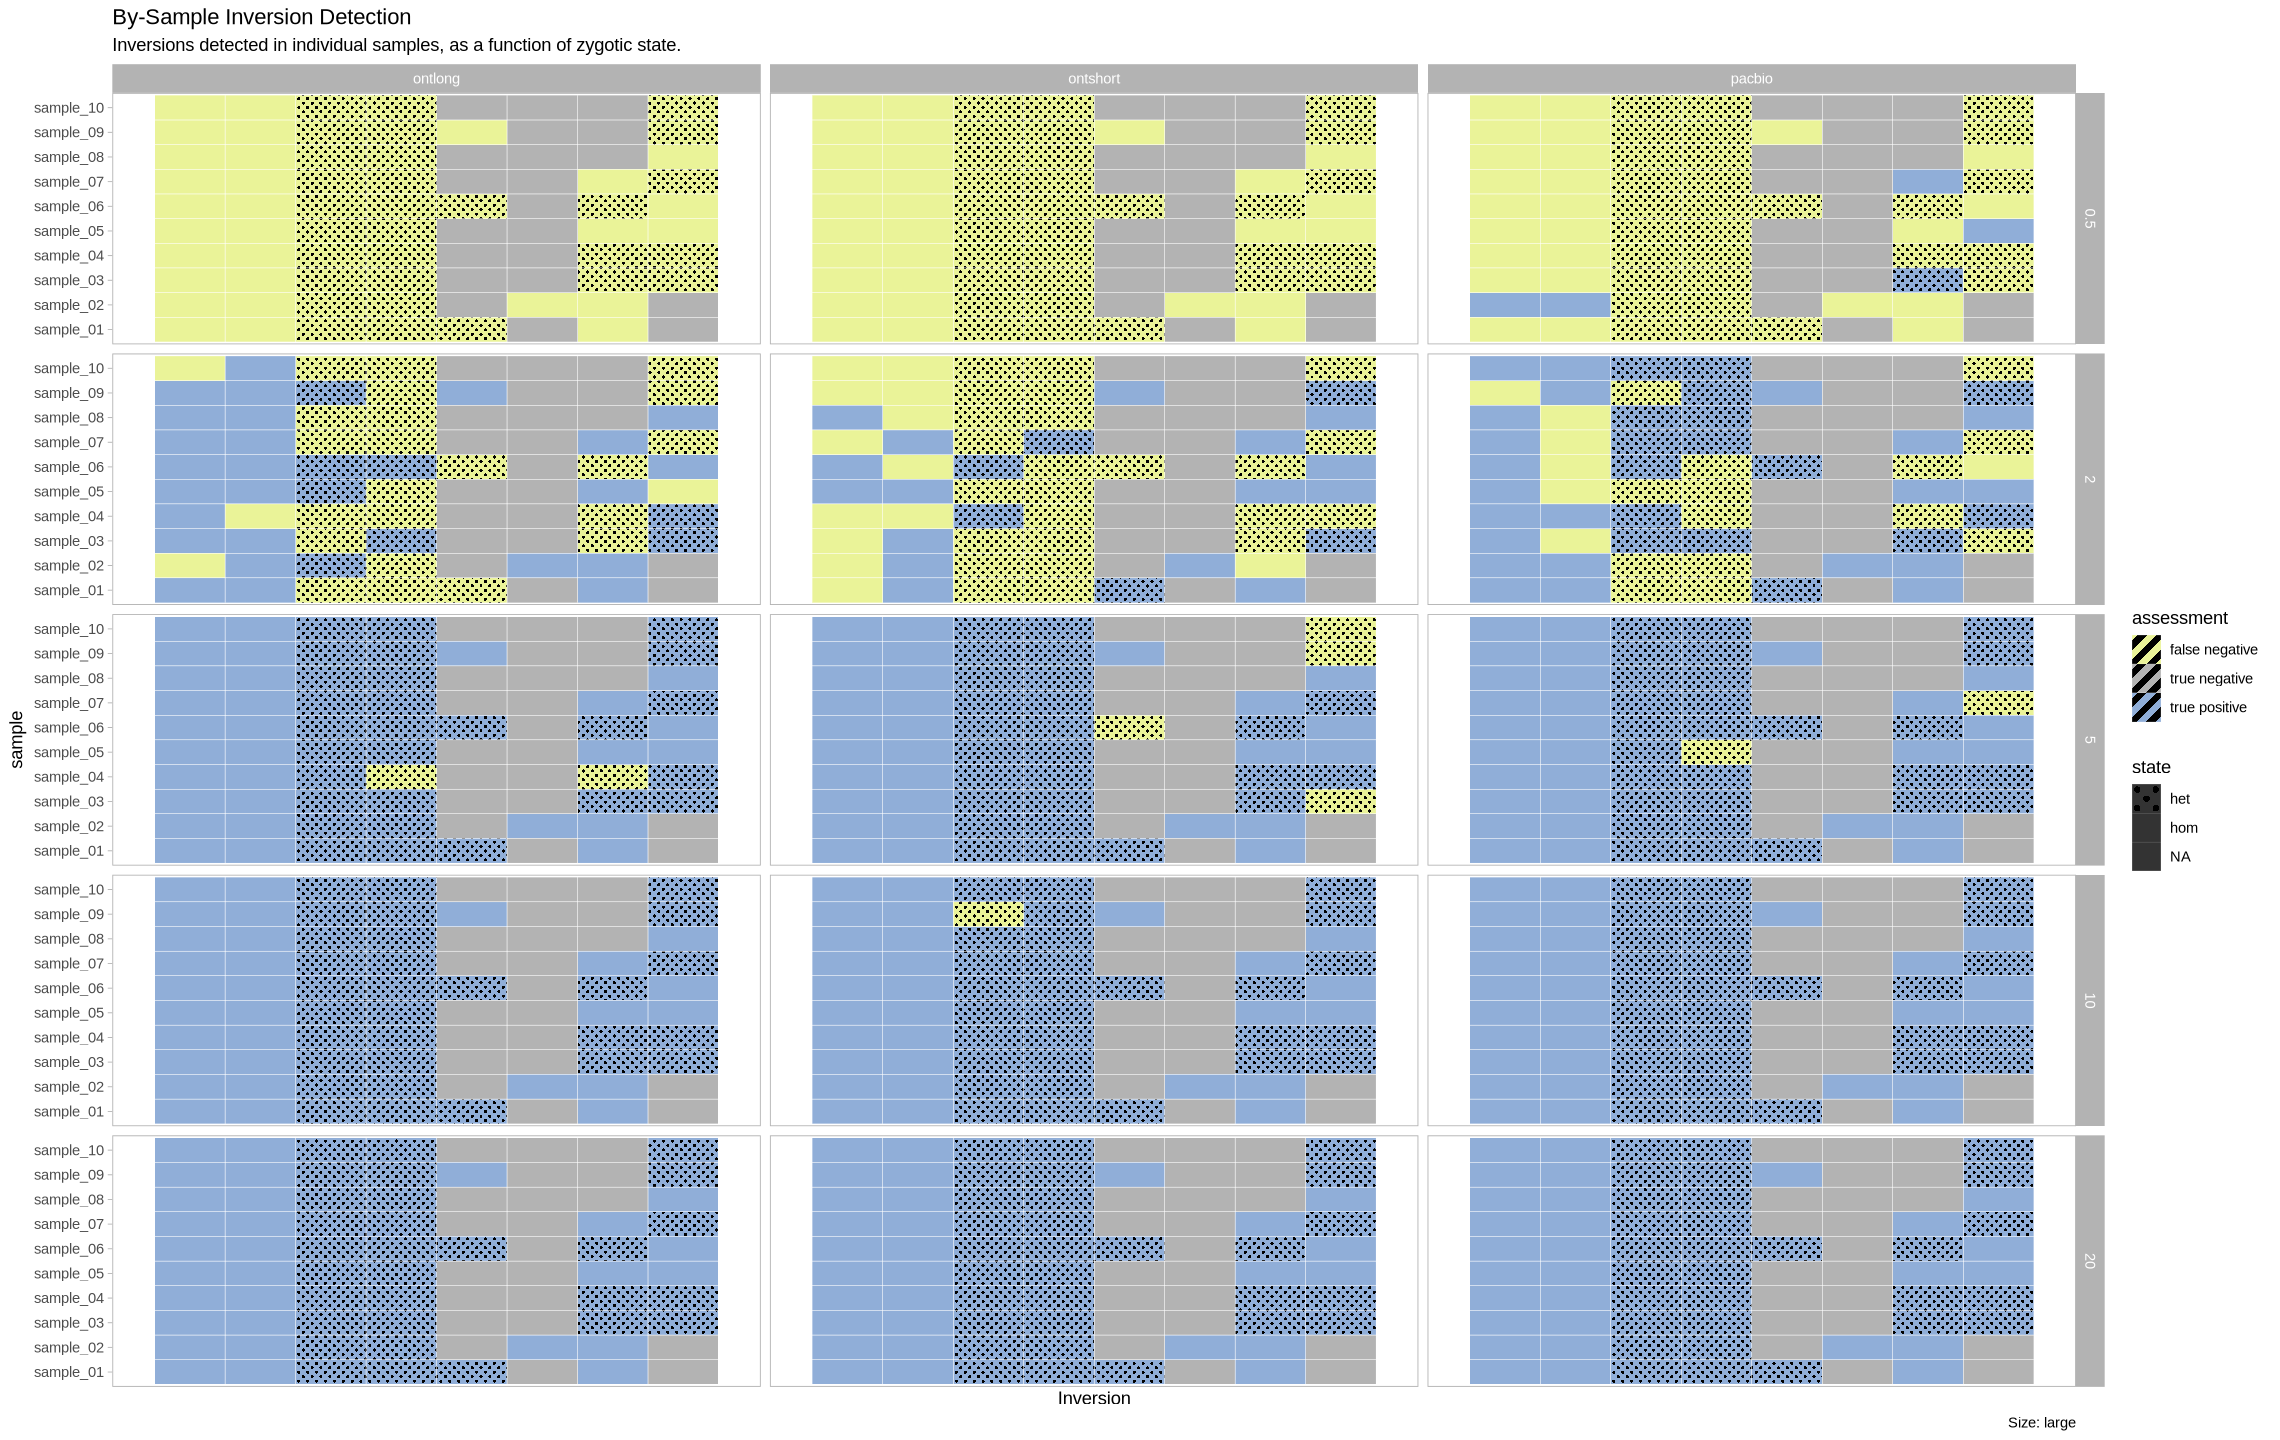

In [14]:
plot_inversions(assessment_df, "large")
plot_samples_matrix(assessment_df, "large")

### XL Inversions

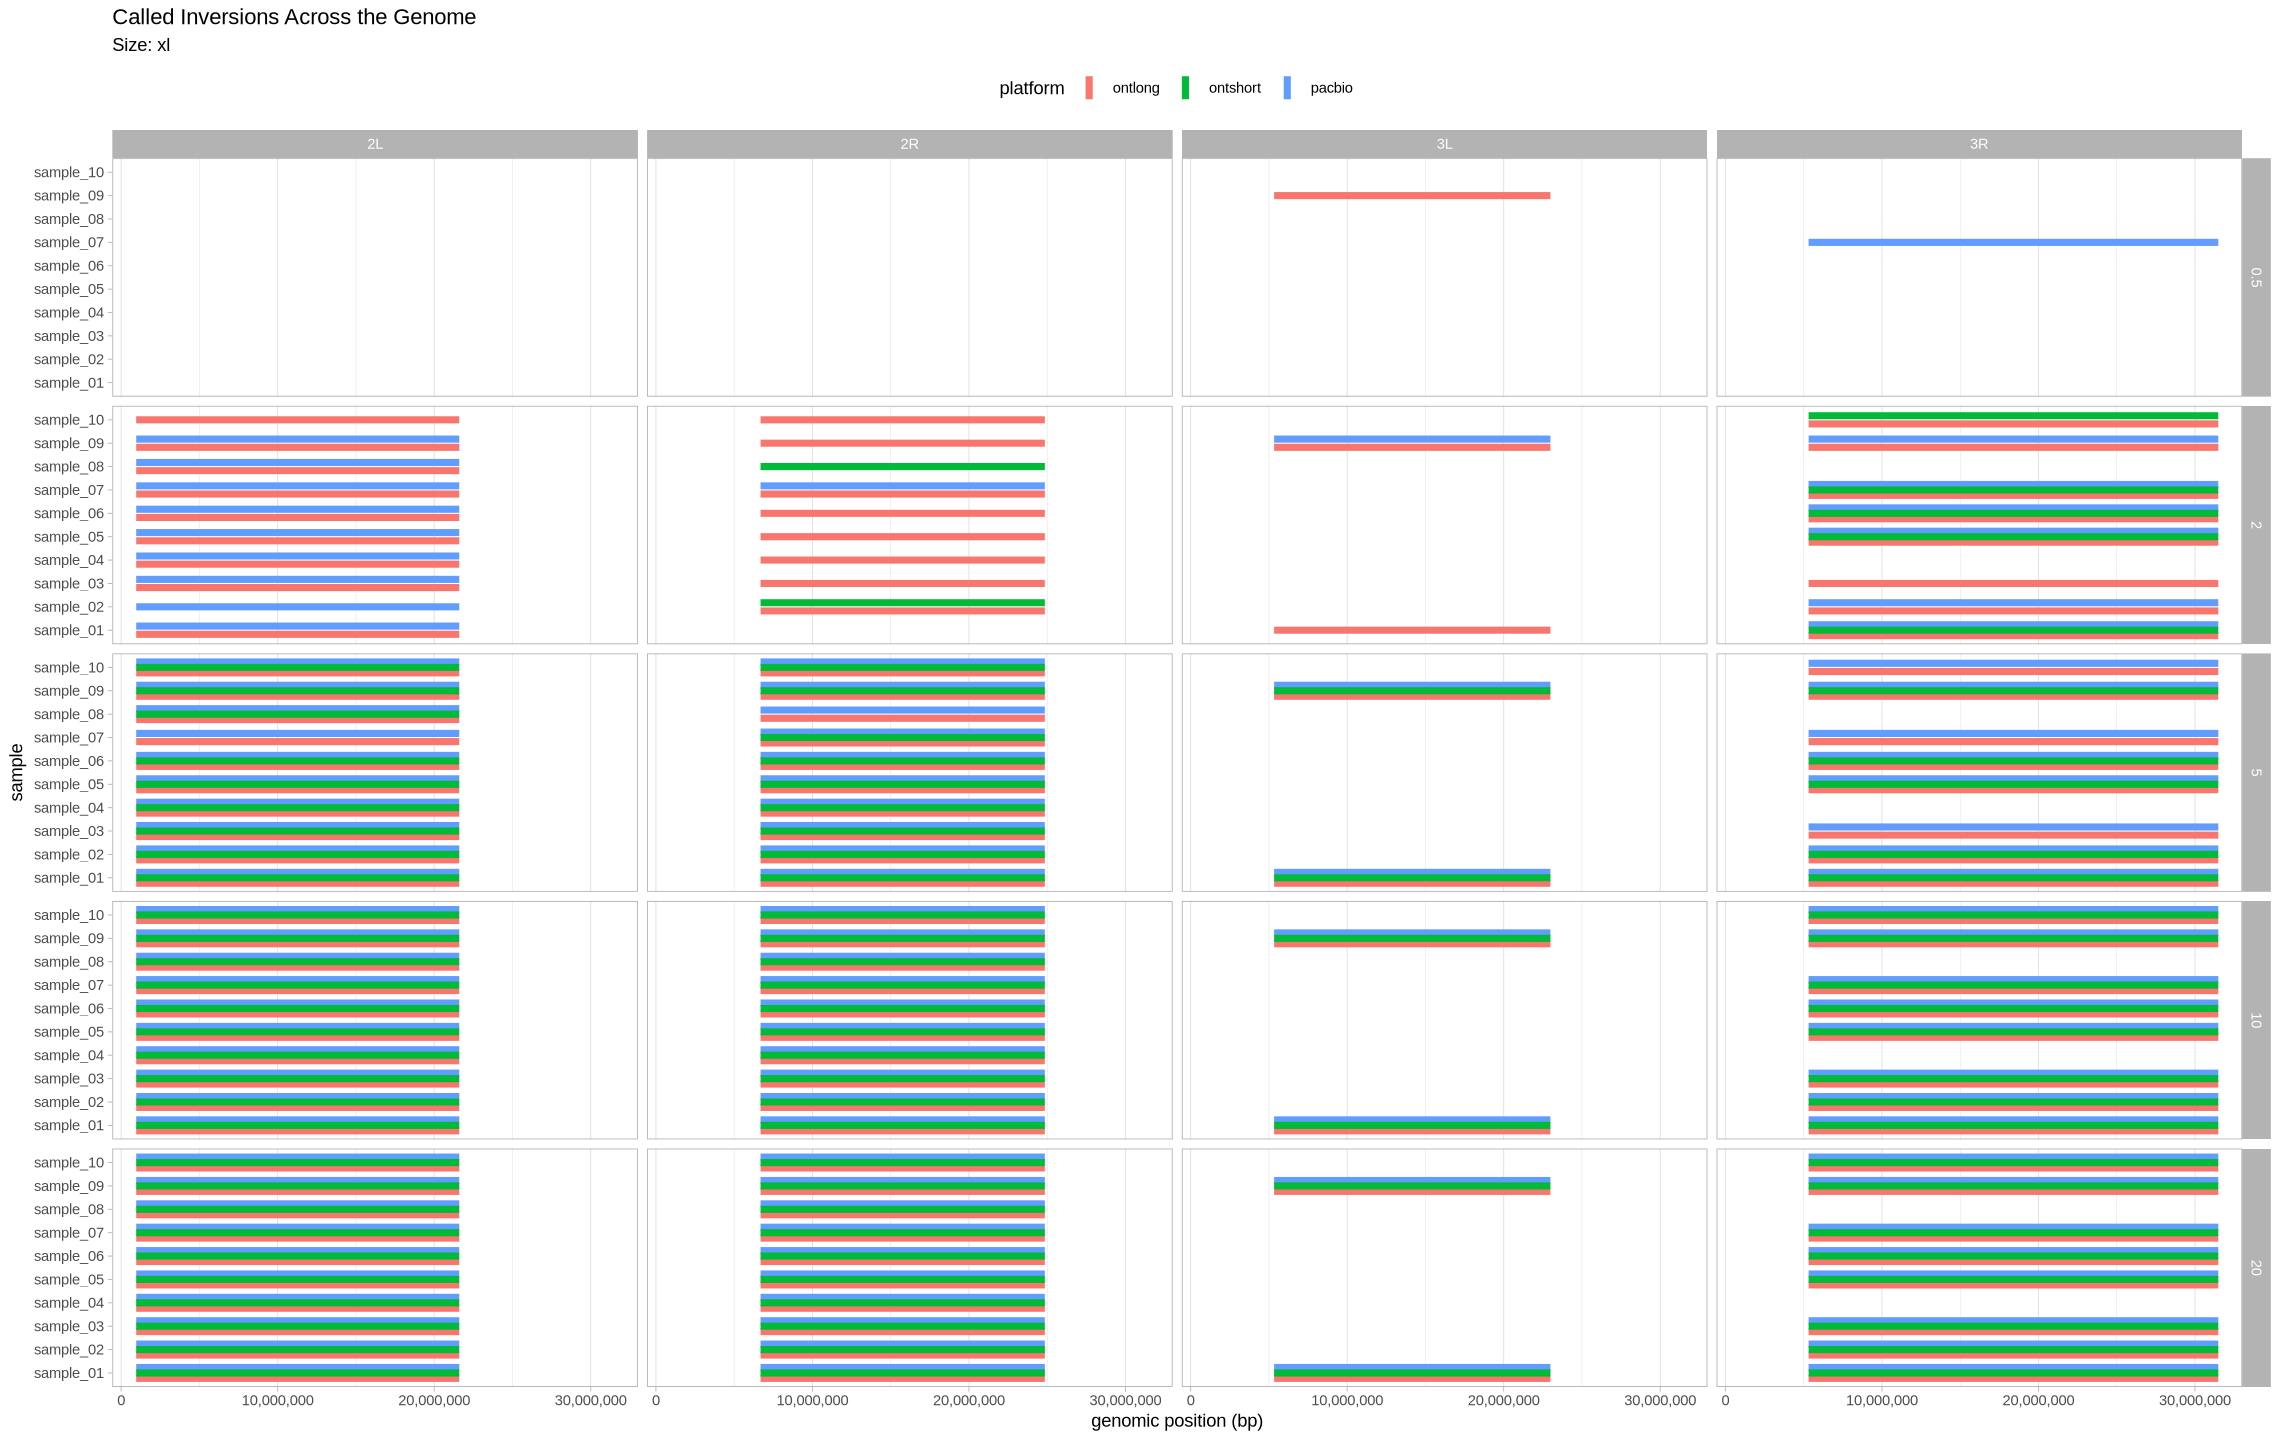

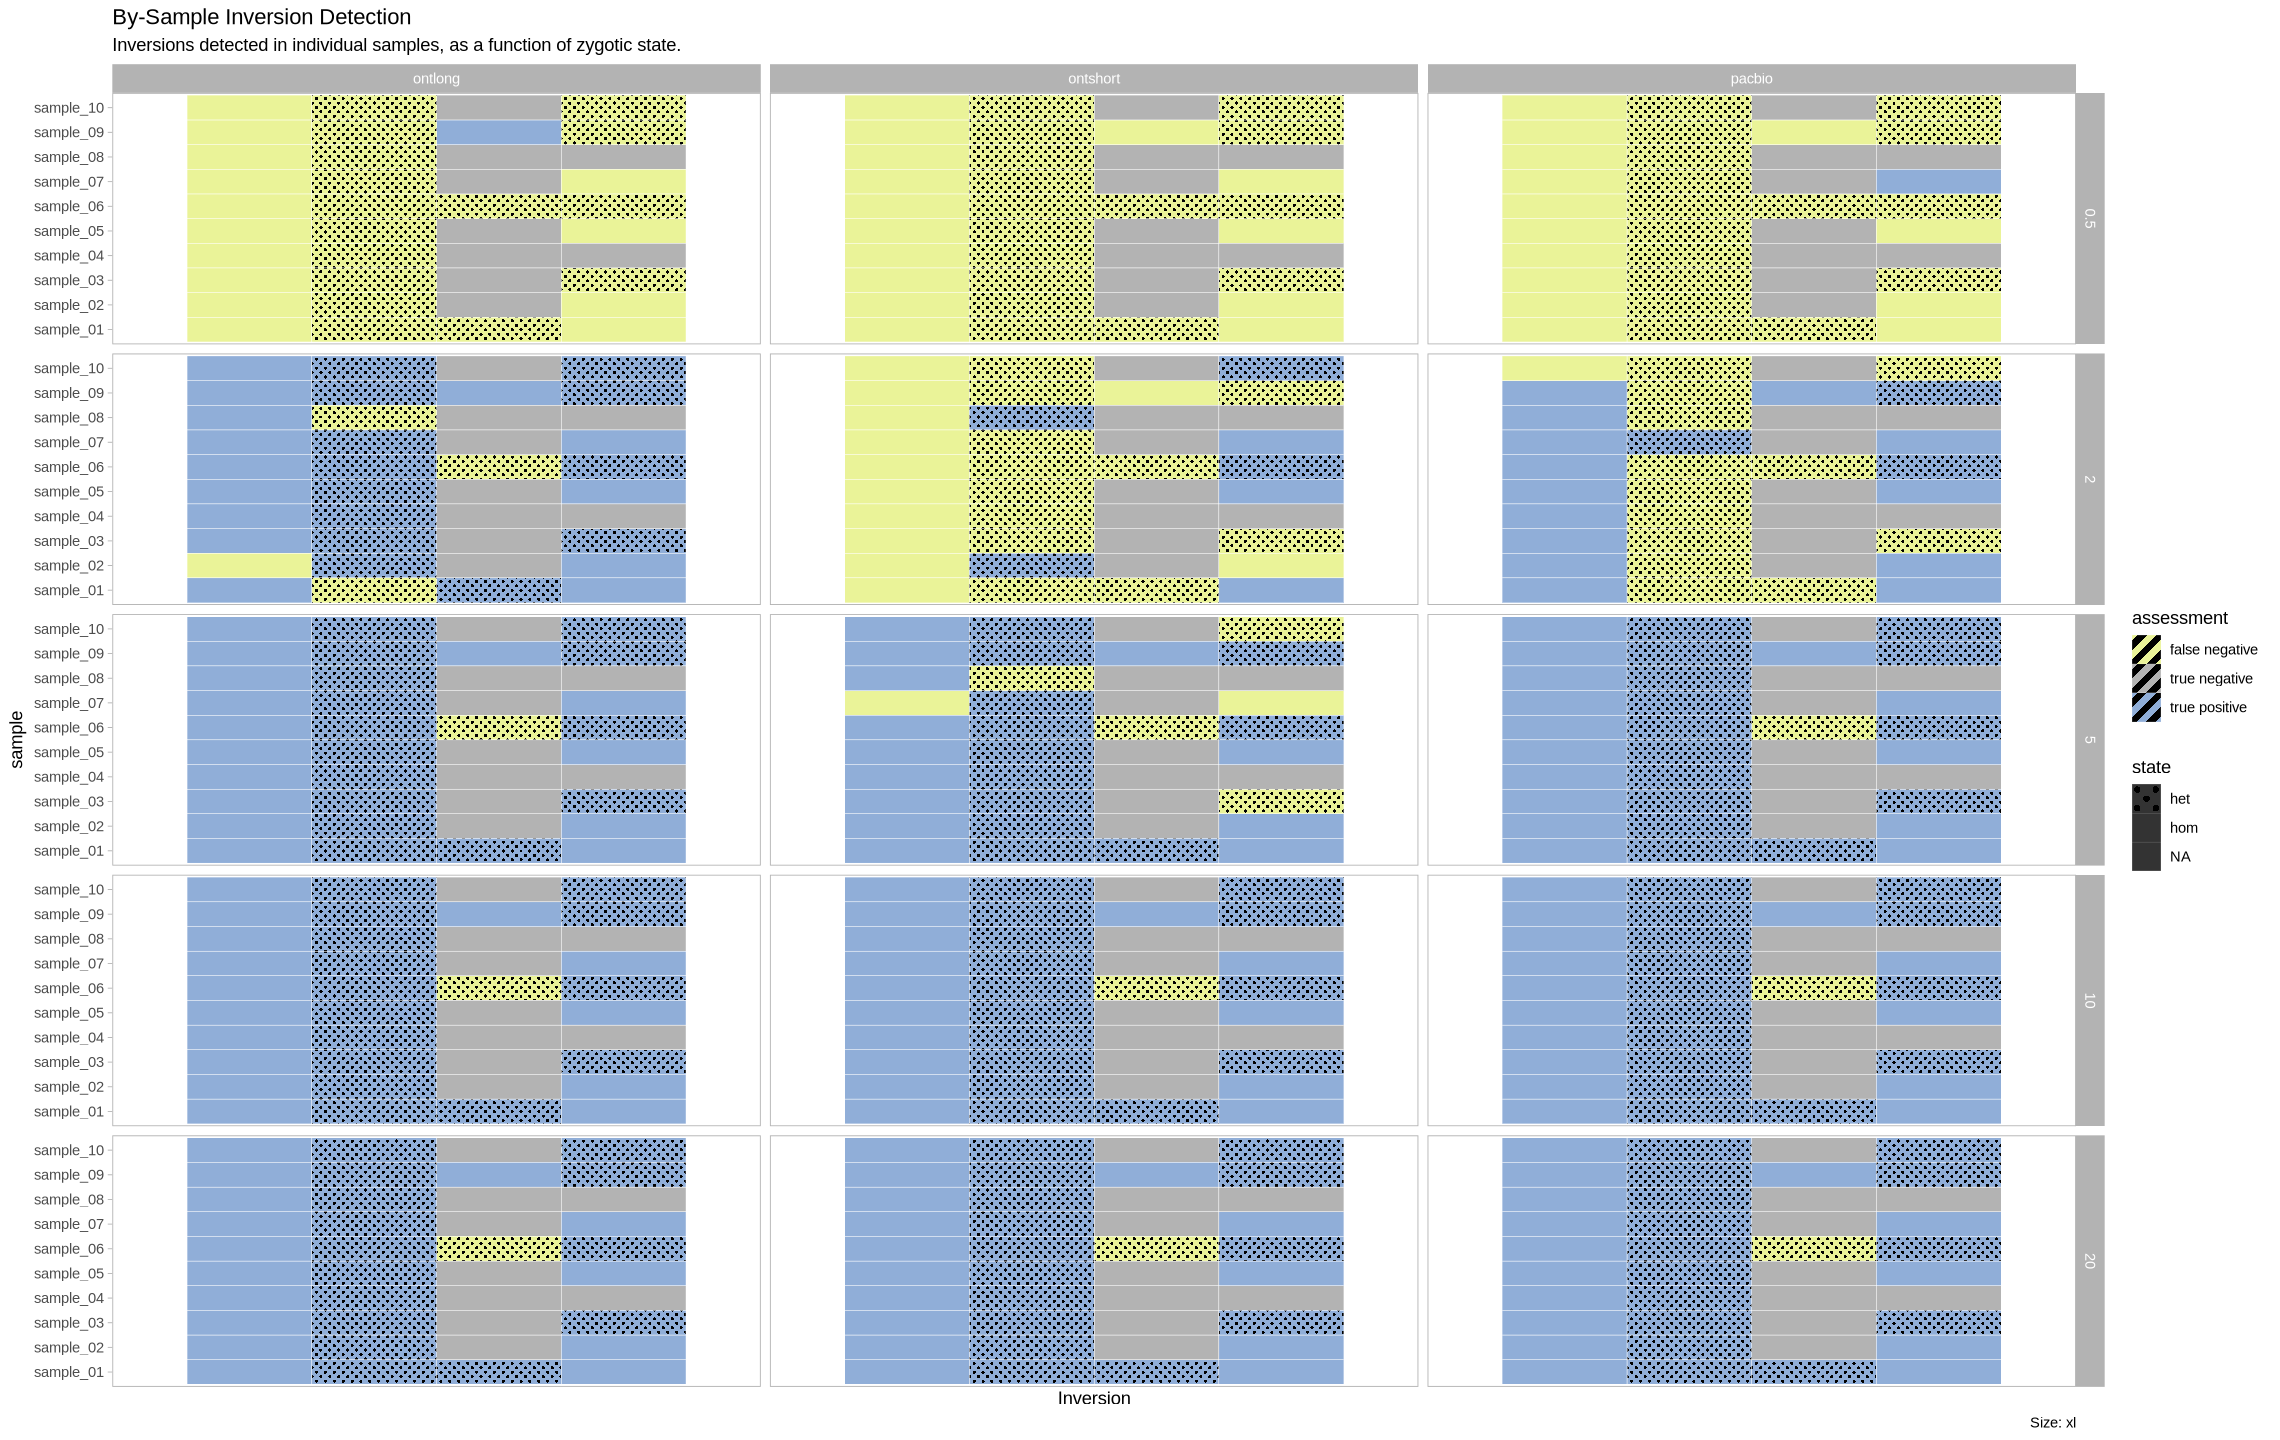

In [15]:
plot_inversions(assessment_df, "xl")
plot_samples_matrix(assessment_df, "xl")